In [11]:
import sys
sys.path.append("..")
import numpy as np

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.data_sim import simulate_uplift_data
from src.dragonnet import TrainConfig, fit_dragonnet, predict_dragonnet
from src.evaluate import (
    summarize_uplift_eval,
    print_eval_summary,
    cumulative_uplift_curve,
    qini_curve_from_probs,
    calibration_by_uplift_bin,
)

# 1. simulate data
df = simulate_uplift_data(n=100_000, seed=42)

feature_cols = [
    "intent",
    "price_sens",
    "visits",
    "recency",
    "mobile",
    "geo_tier",
    "creative_match",
    "remarketing",
]

X = df[feature_cols].to_numpy(dtype=np.float32)
t = df["treatment"].to_numpy(dtype=np.float32)
y = df["outcome"].to_numpy(dtype=np.float32)

p0_true = df["p0_true"].to_numpy(dtype=np.float32)
p1_true = df["p1_true"].to_numpy(dtype=np.float32)
tau_true = df["tau_true"].to_numpy(dtype=np.float32)

# 2. split
(
    X_train,
    X_tmp,
    t_train,
    t_tmp,
    y_train,
    y_tmp,
    p0_train,
    p0_tmp,
    p1_train,
    p1_tmp,
    tau_train,
    tau_tmp,
) = train_test_split(
    X, t, y, p0_true, p1_true, tau_true,
    test_size=0.3,
    random_state=42,
)

(
    X_val,
    X_test,
    t_val,
    t_test,
    y_val,
    y_test,
    p0_val,
    p0_test,
    p1_val,
    p1_test,
    tau_val,
    tau_test,
) = train_test_split(
    X_tmp, t_tmp, y_tmp, p0_tmp, p1_tmp, tau_tmp,
    test_size=0.5,
    random_state=42,
)

# 3. scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. train
import torch

config = TrainConfig(
    batch_size=1024,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=20,
    alpha_propensity=0.5,
    grad_clip_norm=5.0,
    device="cpu",#"cuda" if torch.cuda.is_available() else "cpu",
    verbose=True,
)

model, history = fit_dragonnet(
    X_train=X_train,
    t_train=t_train,
    y_train=y_train,
    X_val=X_val,
    t_val=t_val,
    y_val=y_val,
    hidden_dim=128,
    num_shared_layers=2,
    num_head_layers=1,
    dropout=0.1,
    config=config,
)

# 5. predict
pred = predict_dragonnet(
    model=model,
    X=X_test,
    batch_size=4096,
    device=config.device,
)

tau_hat = pred["tau_hat"]

# 6. summary metrics
summary = summarize_uplift_eval(
    tau_true=tau_test,
    tau_hat=tau_hat,
    p0_true=p0_test,
    p1_true=p1_test,
    frac=0.10,
)
print_eval_summary(summary)

# 7. curve dataframes
uplift_curve_df = cumulative_uplift_curve(
    tau_true=tau_test,
    tau_hat=tau_hat,
    n_points=20,
)

qini_df = qini_curve_from_probs(
    p0_true=p0_test,
    p1_true=p1_test,
    tau_hat=tau_hat,
    n_points=20,
)

calib_df = calibration_by_uplift_bin(
    tau_true=tau_test,
    tau_hat=tau_hat,
    n_bins=10,
)

print("\nUplift curve head:")
print(uplift_curve_df.head())

print("\nQini curve head:")
print(qini_df.head())

print("\nCalibration by uplift bin:")
print(calib_df)

[Epoch 01] train_loss=0.86497 val_loss=0.72841 train_outcome=0.56410 val_outcome=0.45068 train_prop=0.60173 val_prop=0.55545
[Epoch 02] train_loss=0.71806 val_loss=0.66178 train_outcome=0.43199 val_outcome=0.38502 train_prop=0.57213 val_prop=0.55352
[Epoch 03] train_loss=0.66438 val_loss=0.63738 train_outcome=0.38191 val_outcome=0.36145 train_prop=0.56494 val_prop=0.55187
[Epoch 04] train_loss=0.64740 val_loss=0.63350 train_outcome=0.36670 val_outcome=0.35775 train_prop=0.56142 val_prop=0.55150
[Epoch 05] train_loss=0.64099 val_loss=0.63124 train_outcome=0.36189 val_outcome=0.35583 train_prop=0.55819 val_prop=0.55082
[Epoch 06] train_loss=0.63692 val_loss=0.63158 train_outcome=0.35929 val_outcome=0.35611 train_prop=0.55526 val_prop=0.55096
[Epoch 07] train_loss=0.63645 val_loss=0.63059 train_outcome=0.35873 val_outcome=0.35539 train_prop=0.55544 val_prop=0.55041
[Epoch 08] train_loss=0.63451 val_loss=0.63025 train_outcome=0.35789 val_outcome=0.35503 train_prop=0.55324 val_prop=0.55044


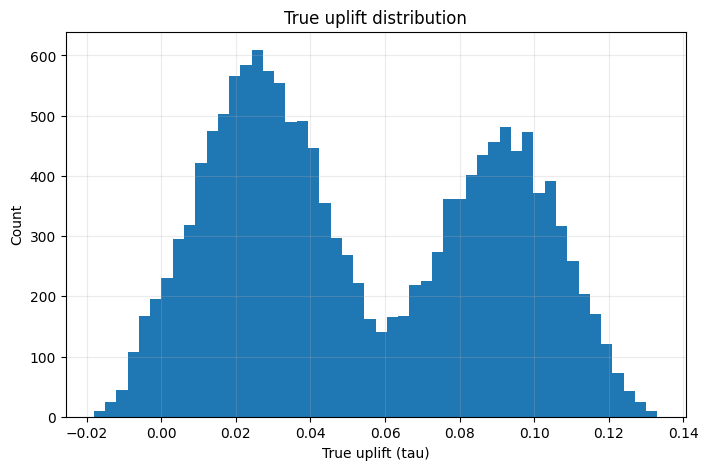

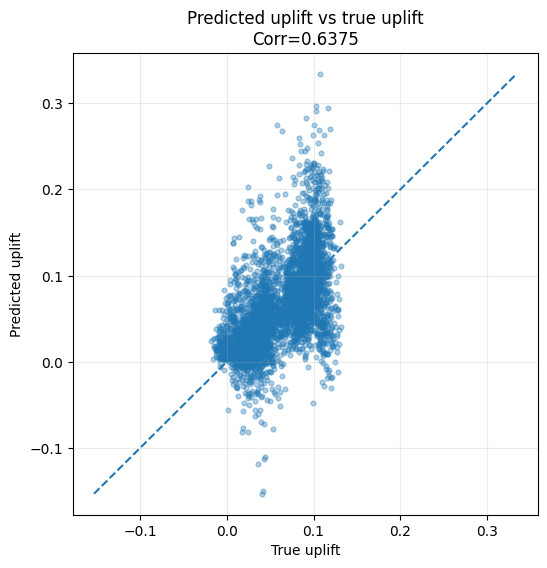

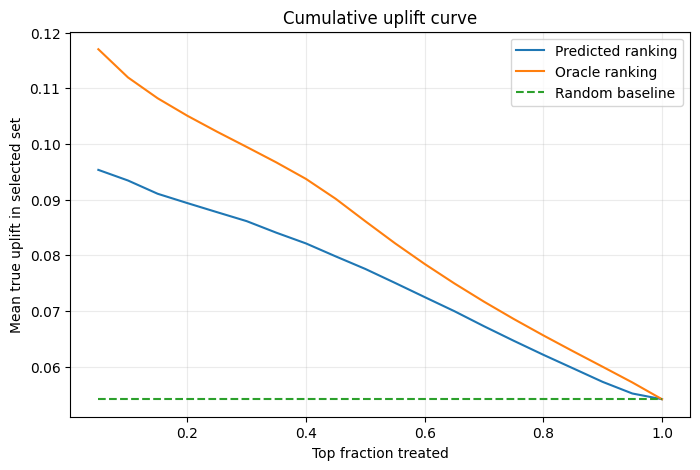

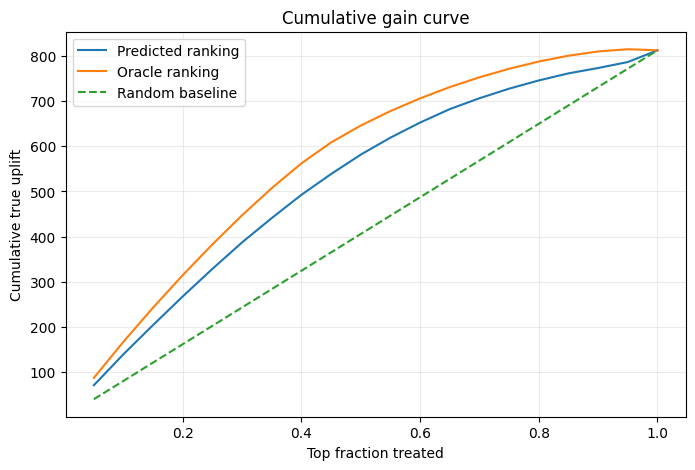

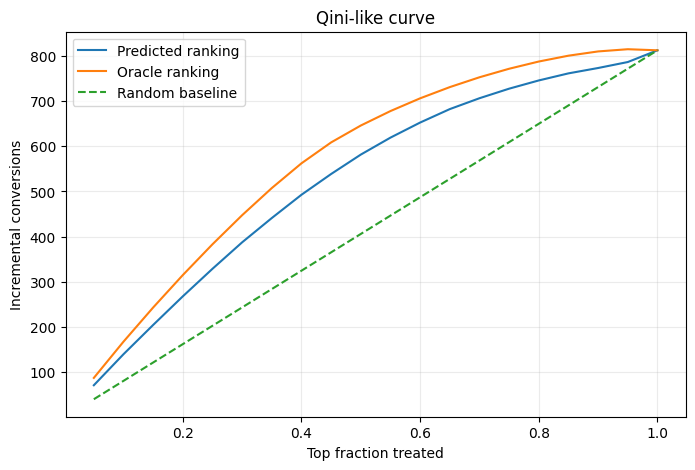

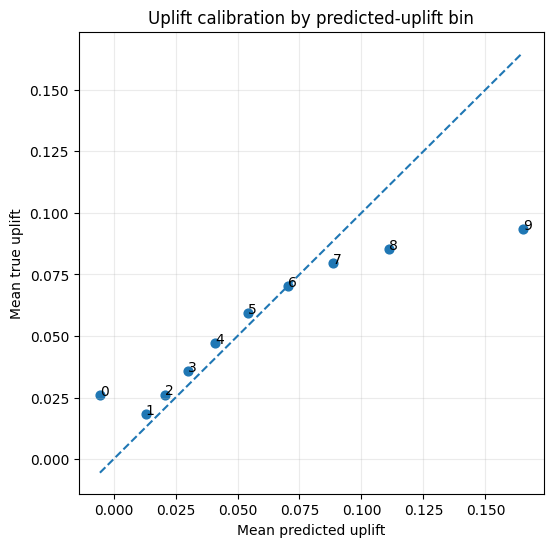

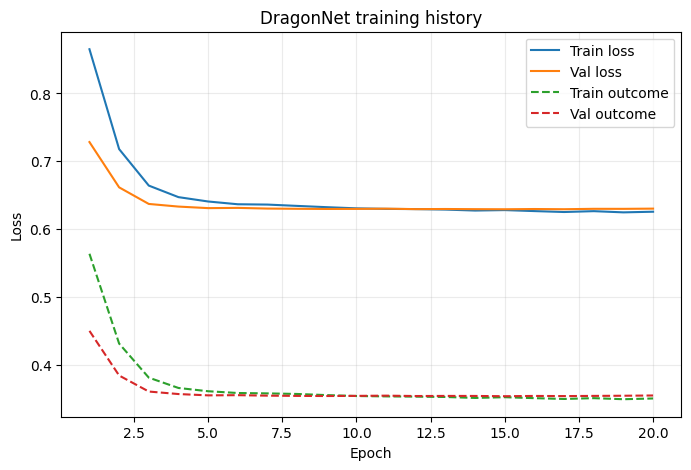

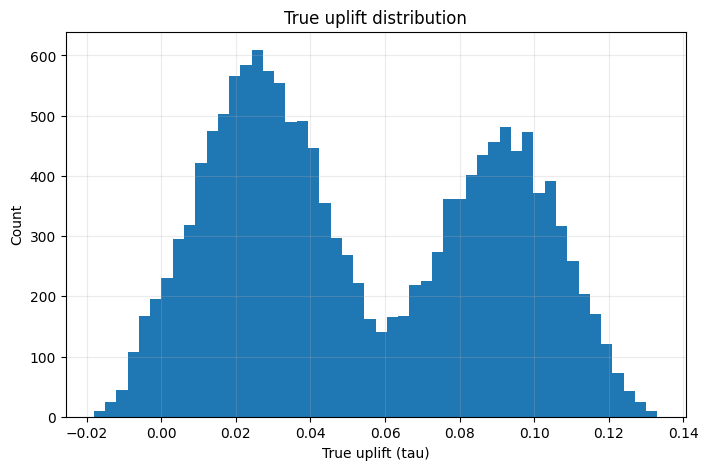

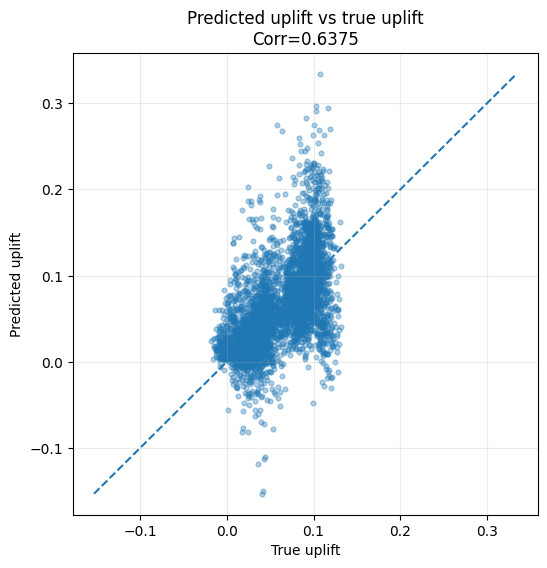

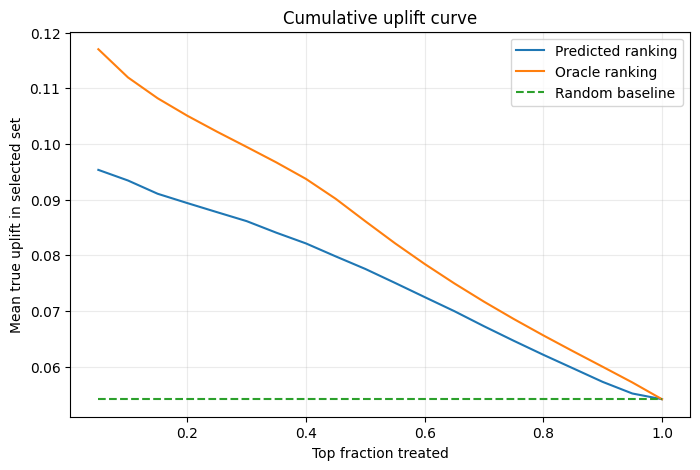

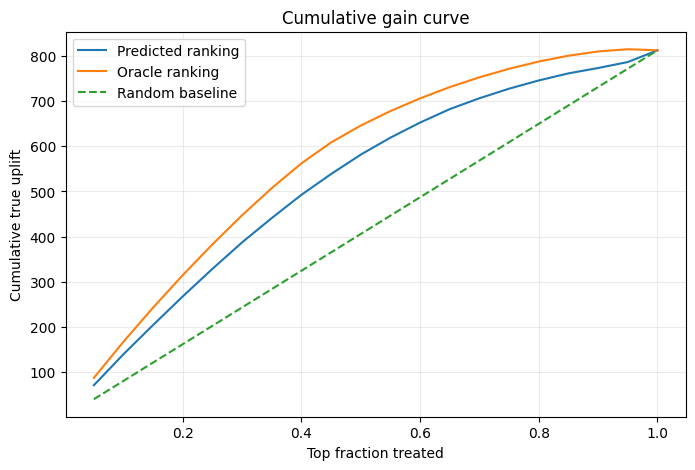

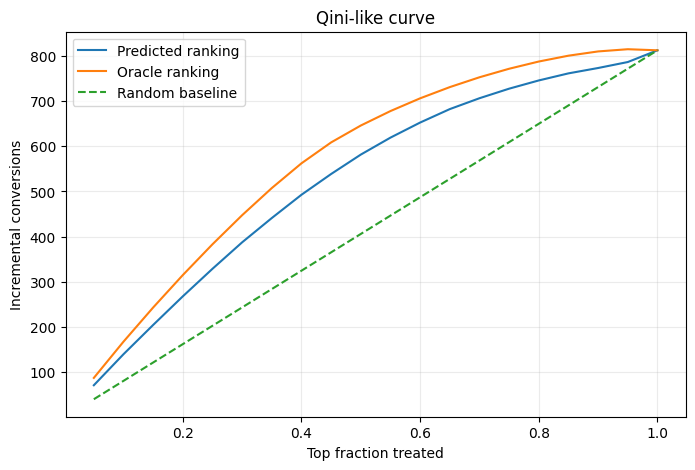

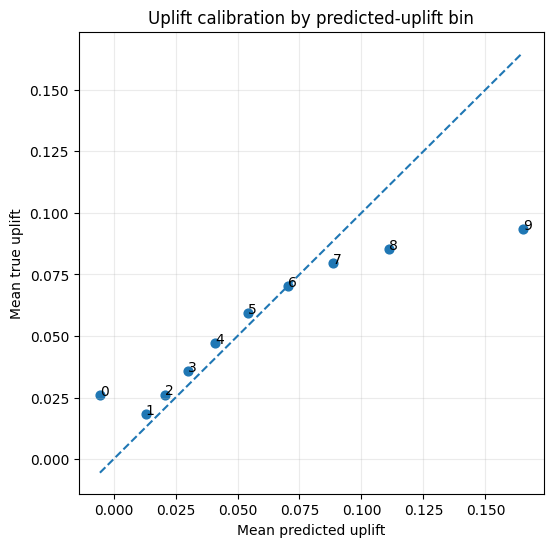

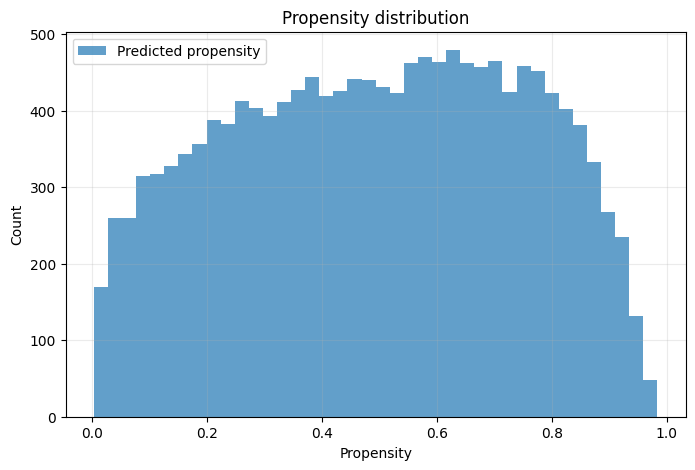

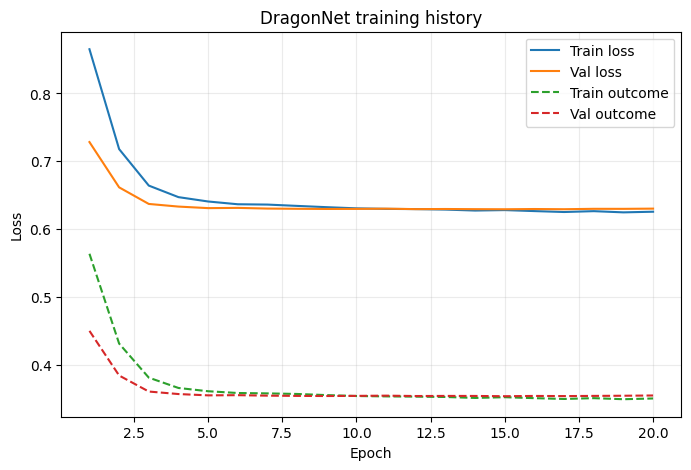

In [13]:
from src.plots import (
    plot_tau_histogram,
    plot_pred_vs_true_uplift,
    plot_uplift_curve,
    plot_cumulative_gain_curve,
    plot_qini_curve,
    plot_uplift_calibration,
    plot_propensity_histogram,
    plot_training_history,
    plot_all_uplift_diagnostics,
)

# after you already computed:
# summary
# uplift_curve_df
# qini_df
# calib_df
# pred
# history
# tau_test
# tau_hat
# and optionally df["propensity_true"] split into propensity_test

# individual plots
plot_tau_histogram(tau_test)
plot_pred_vs_true_uplift(tau_true=tau_test, tau_hat=tau_hat)
plot_uplift_curve(uplift_curve_df)
plot_cumulative_gain_curve(uplift_curve_df)
plot_qini_curve(qini_df)
plot_uplift_calibration(calib_df)
plot_training_history(history)

# if you also have true propensity on test:
# plot_propensity_histogram(
#     propensity_hat=pred["propensity_hat"],
#     propensity_true=propensity_test,
# )

# or generate/save everything at once
plot_all_uplift_diagnostics(
    tau_true=tau_test,
    tau_hat=tau_hat,
    uplift_curve_df=uplift_curve_df,
    qini_df=qini_df,
    calib_df=calib_df,
    history=history,
    propensity_hat=pred["propensity_hat"],
    # propensity_true=propensity_test,
    output_dir="images",
    show=True,
)

[Epoch 01] train_loss=0.86305 val_loss=0.71737 train_outcome=0.56002 val_outcome=0.43757 train_prop=0.60606 val_prop=0.55960
[Epoch 02] train_loss=0.71859 val_loss=0.66008 train_outcome=0.43325 val_outcome=0.38234 train_prop=0.57069 val_prop=0.55549
[Epoch 03] train_loss=0.66629 val_loss=0.63694 train_outcome=0.38390 val_outcome=0.36008 train_prop=0.56478 val_prop=0.55373
[Epoch 04] train_loss=0.64791 val_loss=0.63346 train_outcome=0.36702 val_outcome=0.35663 train_prop=0.56176 val_prop=0.55366
[Epoch 05] train_loss=0.64218 val_loss=0.63205 train_outcome=0.36342 val_outcome=0.35600 train_prop=0.55752 val_prop=0.55210
[Epoch 06] train_loss=0.63874 val_loss=0.63272 train_outcome=0.36098 val_outcome=0.35682 train_prop=0.55552 val_prop=0.55179
[Epoch 07] train_loss=0.63628 val_loss=0.63073 train_outcome=0.35896 val_outcome=0.35521 train_prop=0.55465 val_prop=0.55105
[Epoch 08] train_loss=0.63400 val_loss=0.63044 train_outcome=0.35706 val_outcome=0.35475 train_prop=0.55388 val_prop=0.55138


/home/riffxu/venvs/ctr/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/riffxu/venvs/ctr/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Naive observed ATE: 0.170674
True ATE on test  : 0.054137

=== DragonNet ===
pehe                        : 0.040749
ate_true                    : 0.054137
ate_hat                     : 0.055159
ate_error                   : 0.001023
uplift_at_10                : 0.089215
oracle_uplift_at_10         : 0.111931
policy_value_at_10          : 0.139797
oracle_policy_value_at_10   : 0.142069
policy_gain_at_10           : 0.008922
oracle_policy_gain_at_10    : 0.011193

=== T-learner ===
pehe                        : 0.061835
ate_true                    : 0.054137
ate_hat                     : 0.059614
ate_error                   : 0.005477
uplift_at_10                : 0.091900
oracle_uplift_at_10         : 0.111931
policy_value_at_10          : 0.140066
oracle_policy_value_at_10   : 0.142069
policy_gain_at_10           : 0.009190
oracle_policy_gain_at_10    : 0.011193


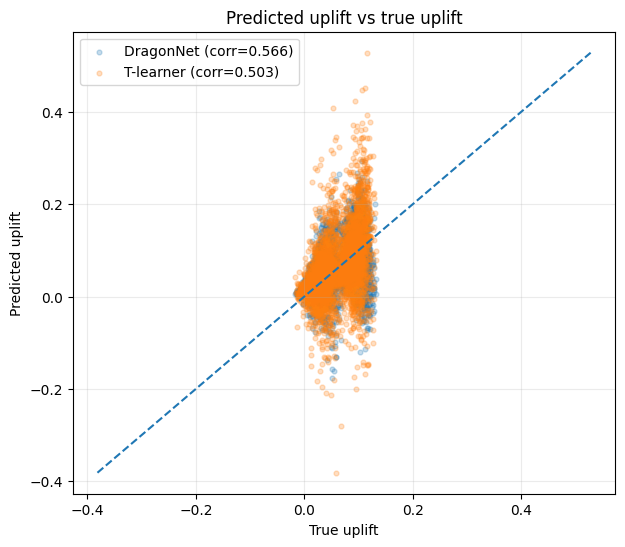

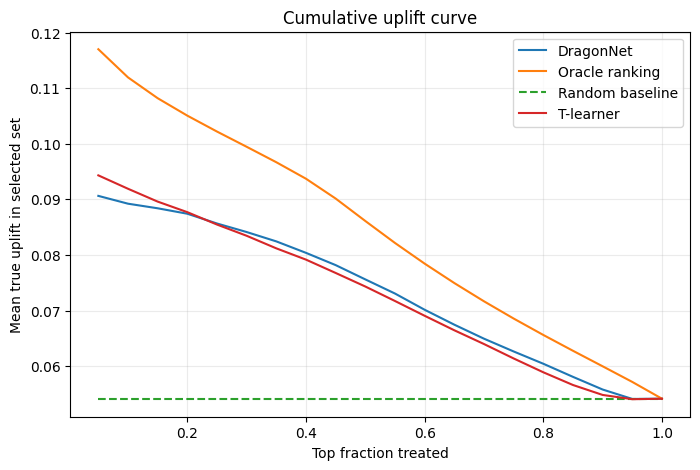

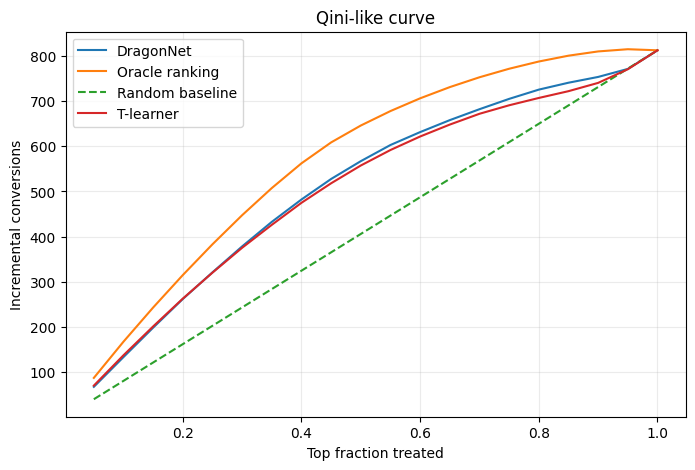

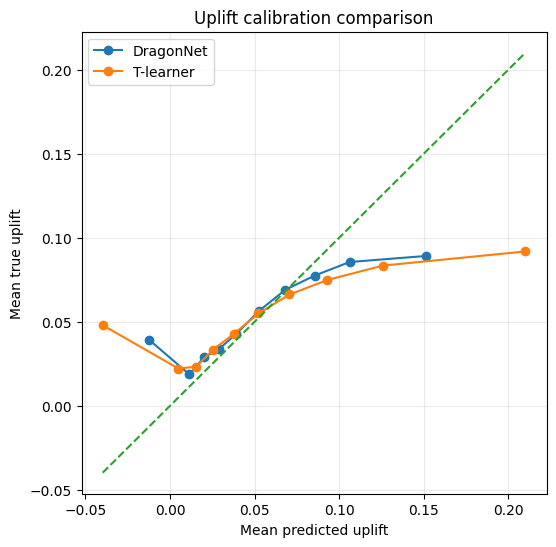

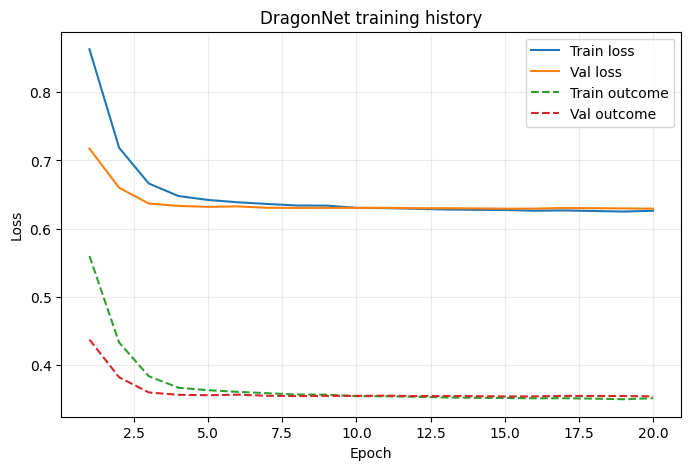

In [14]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.data_sim import simulate_uplift_data
from src.dragonnet import TrainConfig, fit_dragonnet, predict_dragonnet
from src.baselines import TLearner, TClassifierConfig, naive_ate_difference_in_means
from src.evaluate import (
    summarize_uplift_eval,
    print_eval_summary,
    cumulative_uplift_curve,
    qini_curve_from_probs,
    calibration_by_uplift_bin,
)
from src.plots import (
    plot_uplift_curve_compare,
    plot_qini_curve_compare,
    plot_pred_vs_true_uplift_compare,
    plot_calibration_compare,
    plot_training_history,
)

# 1. simulate data
df = simulate_uplift_data(n=100_000, seed=42)

feature_cols = [
    "intent",
    "price_sens",
    "visits",
    "recency",
    "mobile",
    "geo_tier",
    "creative_match",
    "remarketing",
]

X = df[feature_cols].to_numpy(dtype=np.float32)
t = df["treatment"].to_numpy(dtype=np.float32)
y = df["outcome"].to_numpy(dtype=np.float32)
p0_true = df["p0_true"].to_numpy(dtype=np.float32)
p1_true = df["p1_true"].to_numpy(dtype=np.float32)
tau_true = df["tau_true"].to_numpy(dtype=np.float32)

(
    X_train,
    X_tmp,
    t_train,
    t_tmp,
    y_train,
    y_tmp,
    p0_train,
    p0_tmp,
    p1_train,
    p1_tmp,
    tau_train,
    tau_tmp,
) = train_test_split(
    X, t, y, p0_true, p1_true, tau_true,
    test_size=0.3,
    random_state=42,
)

(
    X_val,
    X_test,
    t_val,
    t_test,
    y_val,
    y_test,
    p0_val,
    p0_test,
    p1_val,
    p1_test,
    tau_val,
    tau_test,
) = train_test_split(
    X_tmp, t_tmp, y_tmp, p0_tmp, p1_tmp, tau_tmp,
    test_size=0.5,
    random_state=42,
)

# 2. scale for DragonNet
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 3. DragonNet
config = TrainConfig(
    batch_size=1024,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=20,
    alpha_propensity=0.5,
    grad_clip_norm=5.0,
    device="cpu",#"cuda" if torch.cuda.is_available() else "cpu",
    verbose=True,
)

dragon_model, history = fit_dragonnet(
    X_train=X_train_scaled,
    t_train=t_train,
    y_train=y_train,
    X_val=X_val_scaled,
    t_val=t_val,
    y_val=y_val,
    hidden_dim=128,
    num_shared_layers=2,
    num_head_layers=1,
    dropout=0.1,
    config=config,
)

dragon_pred = predict_dragonnet(
    model=dragon_model,
    X=X_test_scaled,
    batch_size=4096,
    device=config.device,
)
tau_hat_dragon = dragon_pred["tau_hat"]

# 4. T-learner
tlearner = TLearner(
    TClassifierConfig(
        model_type="lightgbm",
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
    )
)
tlearner.fit(X_train, t_train, y_train)
t_pred = tlearner.predict(X_test)
tau_hat_t = t_pred["tau_hat"]

# 5. naive ATE
naive_ate = naive_ate_difference_in_means(t_test, y_test)
print(f"Naive observed ATE: {naive_ate:.6f}")
print(f"True ATE on test  : {tau_test.mean():.6f}")

# 6. summaries
print("\n=== DragonNet ===")
dragon_summary = summarize_uplift_eval(
    tau_true=tau_test,
    tau_hat=tau_hat_dragon,
    p0_true=p0_test,
    p1_true=p1_test,
    frac=0.10,
)
print_eval_summary(dragon_summary)

print("\n=== T-learner ===")
t_summary = summarize_uplift_eval(
    tau_true=tau_test,
    tau_hat=tau_hat_t,
    p0_true=p0_test,
    p1_true=p1_test,
    frac=0.10,
)
print_eval_summary(t_summary)

# 7. curve dfs
dragon_curve_df = cumulative_uplift_curve(
    tau_true=tau_test,
    tau_hat=tau_hat_dragon,
    n_points=20,
)
t_curve_df = cumulative_uplift_curve(
    tau_true=tau_test,
    tau_hat=tau_hat_t,
    n_points=20,
)

dragon_qini_df = qini_curve_from_probs(
    p0_true=p0_test,
    p1_true=p1_test,
    tau_hat=tau_hat_dragon,
    n_points=20,
)
t_qini_df = qini_curve_from_probs(
    p0_true=p0_test,
    p1_true=p1_test,
    tau_hat=tau_hat_t,
    n_points=20,
)

dragon_calib_df = calibration_by_uplift_bin(
    tau_true=tau_test,
    tau_hat=tau_hat_dragon,
    n_bins=10,
)
t_calib_df = calibration_by_uplift_bin(
    tau_true=tau_test,
    tau_hat=tau_hat_t,
    n_bins=10,
)

# 8. side-by-side plots
plot_pred_vs_true_uplift_compare(
    tau_true=tau_test,
    pred_dict={
        "DragonNet": tau_hat_dragon,
        "T-learner": tau_hat_t,
    },
    save_path="images/pred_vs_true_compare.png",
    show=True,
)

plot_uplift_curve_compare(
    curve_dict={
        "DragonNet": dragon_curve_df,
        "T-learner": t_curve_df,
    },
    save_path="images/uplift_curve_compare.png",
    show=True,
)

plot_qini_curve_compare(
    qini_dict={
        "DragonNet": dragon_qini_df,
        "T-learner": t_qini_df,
    },
    save_path="images/qini_curve_compare.png",
    show=True,
)

plot_calibration_compare(
    calib_dict={
        "DragonNet": dragon_calib_df,
        "T-learner": t_calib_df,
    },
    save_path="images/calibration_compare.png",
    show=True,
)

plot_training_history(
    history=history,
    save_path="images/dragonnet_training_history.png",
    show=True,
)